# 01_train_transaction.ipynb

## End-to-End Machine Learning Pipeline for Online Fraud Detection

This notebook implements a complete end-to-end machine learning pipeline for online transaction fraud classification using `train_transaction.csv`.

**Objective:** predict whether a transaction is fraudulent (`isFraud = 1`) or legitimate (`isFraud = 0`).

**Workflow:**
1. Environment setup
2. Dataset loading from Google Drive
3. Exploratory Data Analysis (EDA)
4. Data cleaning and feature selection
5. Train-test split
6. Preprocessing pipeline
7. Baseline model training
8. Hyperparameter tuning using Optuna
9. Experiment tracking using MLflow
10. Model evaluation
11. Conclusion

> This notebook is intentionally designed to be lightweight and defensive so it can run safely in Google Colab without causing memory issues.

In [1]:
# ============================================================
# 1. Install required dependencies if missing
# ============================================================

import sys
import subprocess
import importlib.util


def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("optuna")
install_if_missing("mlflow")

Installing optuna ...
Installing mlflow ...


In [2]:
# ============================================================
# 2. Import libraries
# ============================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import optuna
import mlflow
import mlflow.sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The dataset is loaded from Google Drive using this path:

```python
/content/drive/MyDrive/train_transaction.csv
```

By default, this notebook uses a sample of the dataset to reduce the risk of out-of-memory errors. If your runtime has enough resources, you can set `USE_SAMPLE = False` to use the full dataset.

In [3]:
# ============================================================
# 3. Mount Google Drive and load dataset
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception as e:
    print("Google Drive is already mounted or this is not a Colab environment.")

DATA_PATH = "/content/drive/MyDrive/train_transaction.csv"

USE_SAMPLE = True
NROWS = 120_000

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}. Please make sure train_transaction.csv is located in MyDrive."
    )

if USE_SAMPLE:
    df = pd.read_csv(DATA_PATH, nrows=NROWS)
else:
    df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Mounted at /content/drive
Google Drive mounted successfully.
Dataset loaded successfully.
Dataset shape: (120000, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Exploratory Data Analysis

This section provides a brief overview of the dataset structure, feature types, missing values, and target distribution. Since fraud detection is an imbalanced classification problem, accuracy alone is not sufficient for evaluation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 360.7+ MB
None
Target distribution:


,count
isFraud,
0,117130
1,2870


Fraud rate: 2.3917%


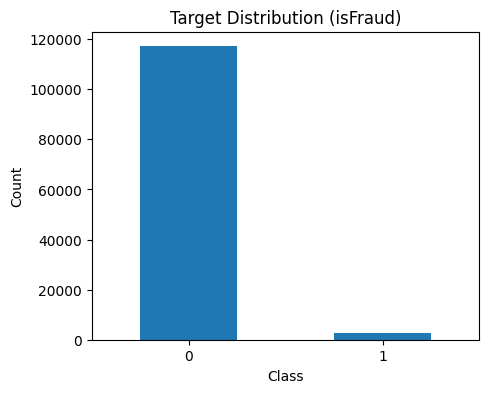

In [4]:
# ============================================================
# 4. Basic EDA
# ============================================================

print(df.info())

if "isFraud" not in df.columns:
    raise ValueError("Target column 'isFraud' not found.")

print("Target distribution:")
display(df["isFraud"].value_counts().to_frame("count"))

fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.4%}")

plt.figure(figsize=(5, 4))
df["isFraud"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution (isFraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [5]:
# ============================================================
# 5. Missing value summary
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

print("Top 20 columns with the highest missing value ratio:")
display(missing_summary.head(20))

Top 20 columns with the highest missing value ratio:


,missing_count,missing_ratio
D7,112531,0.937758
dist2,109739,0.914492
D13,108376,0.903133
D12,107118,0.892650
D14,106319,0.885992
D6,104195,0.868292
M8,101886,0.849050
M9,101886,0.849050
M7,101886,0.849050
D9,92983,0.774858


## 5. Data Cleaning and Defensive Feature Selection

The transaction dataset can contain many columns. To make the pipeline stable and memory-safe, this notebook applies the following steps:

- Remove identifier columns such as `TransactionID`.
- Drop columns with extremely high missing value ratio.
- Limit the number of numeric and categorical features.
- Use preprocessing inside a pipeline to prevent data leakage.

In [6]:
# ============================================================
# 6. Cleaning and defensive feature selection
# ============================================================

TARGET = "isFraud"
ID_COLS = [col for col in ["TransactionID"] if col in df.columns]

MISSING_THRESHOLD = 0.90
high_missing_cols = missing_summary[missing_summary["missing_ratio"] > MISSING_THRESHOLD].index.tolist()
high_missing_cols = [col for col in high_missing_cols if col != TARGET]

X = df.drop(columns=[TARGET] + ID_COLS + high_missing_cols, errors="ignore")
y = df[TARGET].astype(int)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

MAX_NUMERIC_FEATURES = 80
MAX_CATEGORICAL_FEATURES = 15

if len(numeric_cols) > 0:
    numeric_rank = pd.DataFrame({
        "col": numeric_cols,
        "missing_ratio": X[numeric_cols].isna().mean().values,
        "nunique": X[numeric_cols].nunique(dropna=True).values
    })
    numeric_rank = numeric_rank.query("nunique > 1").sort_values(
        ["missing_ratio", "nunique"], ascending=[True, False]
    )
    selected_numeric_cols = numeric_rank["col"].head(MAX_NUMERIC_FEATURES).tolist()
else:
    selected_numeric_cols = []

if len(categorical_cols) > 0:
    categorical_rank = pd.DataFrame({
        "col": categorical_cols,
        "missing_ratio": X[categorical_cols].isna().mean().values,
        "nunique": X[categorical_cols].nunique(dropna=True).values
    })
    categorical_rank = categorical_rank.query("nunique > 1 and nunique <= 50").sort_values(
        ["missing_ratio", "nunique"], ascending=[True, True]
    )
    selected_categorical_cols = categorical_rank["col"].head(MAX_CATEGORICAL_FEATURES).tolist()
else:
    selected_categorical_cols = []

selected_features = selected_numeric_cols + selected_categorical_cols
if len(selected_features) == 0:
    raise ValueError("No valid features were selected. Please check the dataset structure.")

X = X[selected_features].copy()

del numeric_cols, categorical_cols
gc.collect()

print("Selected numeric features:", len(selected_numeric_cols))
print("Selected categorical features:", len(selected_categorical_cols))
print("Total selected features:", len(selected_features))
print("Sample selected features:", selected_features[:20])

Selected numeric features: 80
Selected categorical features: 11
Total selected features: 91
Sample selected features: ['TransactionDT', 'card1', 'V127', 'TransactionAmt', 'V128', 'V130', 'V314', 'V126', 'V133', 'V134', 'V315', 'V313', 'V132', 'V131', 'C13', 'C1', 'C11', 'V136', 'C6', 'C4']


## 6. Train-Test Split

The data is split into training and testing sets using stratification. Stratification preserves the fraud-to-non-fraud ratio in both subsets, which is important for imbalanced classification.

In [7]:
# ============================================================
# 7. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Training target distribution:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))
print("Testing target distribution:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

X_train shape: (96000, 91)
X_test shape: (24000, 91)
Training target distribution:


,proportion
isFraud,
0,0.976083
1,0.023917


Testing target distribution:


,proportion
isFraud,
0,0.976083
1,0.023917


## 7. Preprocessing Pipeline

The preprocessing stage uses `ColumnTransformer`:

- Numeric features: median imputation and standard scaling.
- Categorical features: most frequent imputation and one-hot encoding.

The `OneHotEncoder` is created with version compatibility handling. Some scikit-learn versions use `sparse_output`, while older versions use `sparse`. This notebook supports both to avoid errors.

In [8]:
# ============================================================
# 8. Preprocessing pipeline
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Version-safe OneHotEncoder:
# - Newer scikit-learn versions use sparse_output
# - Older scikit-learn versions use sparse
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, max_categories=20)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric_cols),
        ("cat", categorical_transformer, selected_categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 8. Baseline Model: Logistic Regression

Logistic Regression is used as a baseline model because it is fast, stable, interpretable, and suitable for binary classification. The parameter `class_weight='balanced'` helps address class imbalance.

In [9]:
# ============================================================
# 9. Baseline Logistic Regression model
# ============================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, baseline_proba),
    "pr_auc": average_precision_score(y_test, baseline_proba)
}

print("Baseline metrics:")
for metric_name, metric_value in baseline_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("Classification report:")
print(classification_report(y_test, baseline_pred, zero_division=0))

Baseline metrics:
accuracy: 0.7752
precision: 0.0739
recall: 0.7282
f1: 0.1342
roc_auc: 0.8217
pr_auc: 0.1509
Classification report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87     23426
           1       0.07      0.73      0.13       574

    accuracy                           0.78     24000
   macro avg       0.53      0.75      0.50     24000
weighted avg       0.97      0.78      0.85     24000



## 9. Hyperparameter Tuning with Optuna

Optuna is used to tune the Logistic Regression regularization strength. The optimization target is **PR-AUC**, which is more informative than accuracy for imbalanced fraud detection.

In [10]:
# ============================================================
# 10. Optuna hyperparameter tuning
# ============================================================

N_TRIALS = 8
TUNING_MAX_ROWS = 50_000

if len(X_train) > TUNING_MAX_ROWS:
    X_tune, _, y_tune, _ = train_test_split(
        X_train,
        y_train,
        train_size=TUNING_MAX_ROWS,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
else:
    X_tune, y_tune = X_train, y_train

X_tune_train, X_tune_valid, y_tune_train, y_tune_valid = train_test_split(
    X_tune,
    y_tune,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_tune
)


def objective(trial):
    C = trial.suggest_float("C", 0.01, 10.0, log=True)

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=C,
            class_weight="balanced",
            solver="saga",
            max_iter=500,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    model.fit(X_tune_train, y_tune_train)
    valid_proba = model.predict_proba(X_tune_valid)[:, 1]
    return average_precision_score(y_tune_valid, valid_proba)

study = optuna.create_study(direction="maximize", study_name="train_transaction_logreg_tuning")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print("Best PR-AUC:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-15 10:53:43,699] A new study created in memory with name: train_transaction_logreg_tuning
[I 2026-05-15 10:54:37,445] Trial 0 finished with value: 0.1569927297313407 and parameters: {'C': 0.0373352636088727}. Best is trial 0 with value: 0.1569927297313407.
[I 2026-05-15 10:55:31,303] Trial 1 finished with value: 0.15628165156096785 and parameters: {'C': 7.3141519586596155}. Best is trial 0 with value: 0.1569927297313407.
[I 2026-05-15 10:56:22,501] Trial 2 finished with value: 0.15658280234650063 and parameters: {'C': 0.11727168612480975}. Best is trial 0 with value: 0.1569927297313407.
[I 2026-05-15 10:57:14,945] Trial 3 finished with value: 0.15701119661972646 and parameters: {'C': 0.04241097980662623}. Best is trial 3 with value: 0.15701119661972646.
[I 2026-05-15 10:58:05,294] Trial 4 finished with value: 0.15730279257321403 and parameters: {'C': 0.014992125071830202}. Best is trial 4 with value: 0.15730279257321403.
[I 2026-05-15 10:58:57,516] Trial 5 finished with valu

Best PR-AUC: 0.15730279257321403
Best parameters: {'C': 0.014992125071830202}


## 10. Final Model Training and MLflow Tracking

The final model is trained using the best hyperparameter from Optuna. MLflow is used to log parameters, metrics, and the trained model.

In [11]:
# ============================================================
# 11. Final model training with MLflow tracking
# ============================================================

mlflow.set_experiment("UTS_Train_Transaction_Fraud_Classification")

best_params = study.best_params

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=best_params.get("C", 1.0),
        class_weight="balanced",
        solver="saga",
        max_iter=700,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

with mlflow.start_run(run_name="logistic_regression_optuna_final"):
    mlflow.log_param("dataset_path", DATA_PATH)
    mlflow.log_param("use_sample", USE_SAMPLE)
    mlflow.log_param("nrows", NROWS if USE_SAMPLE else "full_dataset")
    mlflow.log_param("missing_threshold", MISSING_THRESHOLD)
    mlflow.log_param("max_numeric_features", MAX_NUMERIC_FEATURES)
    mlflow.log_param("max_categorical_features", MAX_CATEGORICAL_FEATURES)
    mlflow.log_params(best_params)

    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)
    y_proba = final_model.predict_proba(X_test)[:, 1]

    final_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

    mlflow.log_metrics(final_metrics)
    mlflow.sklearn.log_model(final_model, "model")

print("Final metrics:")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

2026/05/15 11:01:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 11:01:15 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 11:01:18 INFO mlflow.tracking.fluent: Experiment with name 'UTS_Train_Transaction_Fraud_Classification' does not exist. Creating a new experiment.
2026/05/15 11:04:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 11:04:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final metrics:
accuracy: 0.7770
precision: 0.0743
recall: 0.7265
f1: 0.1348
roc_auc: 0.8207
pr_auc: 0.1514


## 11. Model Evaluation

Because fraud detection is imbalanced, the model is evaluated using multiple metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- ROC curve
- Precision-recall curve

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,18230,5196
Actual 1,157,417


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87     23426
           1       0.07      0.73      0.13       574

    accuracy                           0.78     24000
   macro avg       0.53      0.75      0.50     24000
weighted avg       0.97      0.78      0.85     24000



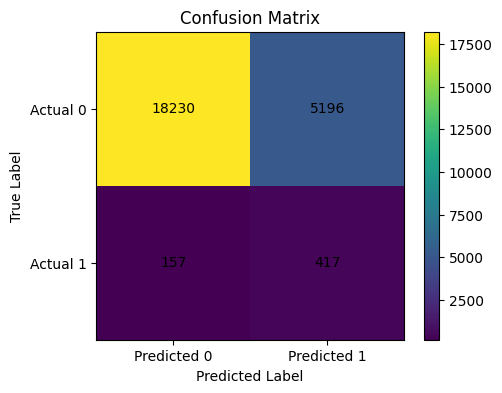

In [12]:
# ============================================================
# 12. Confusion matrix and classification report
# ============================================================

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])

print("Confusion Matrix:")
display(cm_df)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

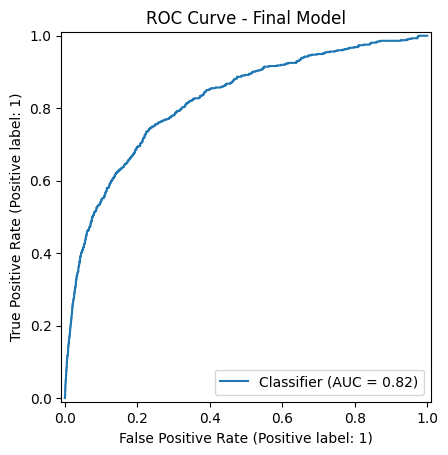

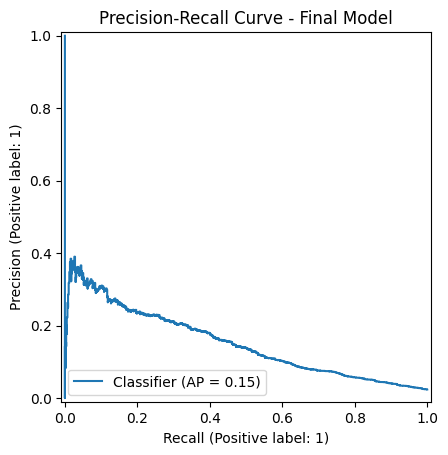

In [13]:
# ============================================================
# 13. ROC curve and Precision-Recall curve
# ============================================================

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Final Model")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve - Final Model")
plt.show()

## 12. Baseline vs Final Model Comparison

This section compares the baseline model with the Optuna-tuned final model. If the improvement is small, that is still acceptable because the number of Optuna trials is intentionally limited for runtime safety.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Baseline Logistic Regression,0.775250,0.073904,0.728223,0.134189,0.821737,0.150856
1,Optuna Tuned Logistic Regression,0.776958,0.074292,0.726481,0.134799,0.820693,0.151384


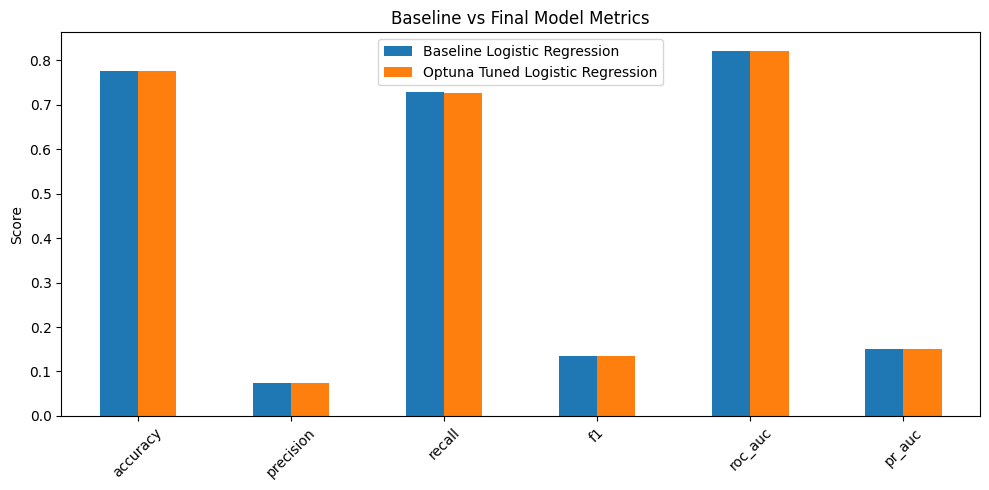

In [14]:
# ============================================================
# 14. Compare baseline and final model metrics
# ============================================================

comparison_df = pd.DataFrame([
    {"model": "Baseline Logistic Regression", **baseline_metrics},
    {"model": "Optuna Tuned Logistic Regression", **final_metrics}
])

display(comparison_df)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
comparison_df.set_index("model")[metric_cols].T.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs Final Model Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 13. Save Output Artifacts

The metric comparison table is saved as a CSV file in Google Drive. This file can be used later for the GitHub repository or README summary.

In [15]:
# ============================================================
# 15. Save output artifacts
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/uts_train_transaction_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison_path = os.path.join(OUTPUT_DIR, "train_transaction_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Metric comparison saved to:", comparison_path)
print("MLflow runs are saved in the mlruns directory of the current runtime.")

Metric comparison saved to: /content/drive/MyDrive/uts_train_transaction_outputs/train_transaction_model_comparison.csv
MLflow runs are saved in the mlruns directory of the current runtime.


## 14. Conclusion

This notebook successfully implements an end-to-end fraud classification pipeline for `train_transaction.csv`. The workflow includes data loading, EDA, missing value handling, defensive feature selection, preprocessing, baseline modeling, Optuna hyperparameter tuning, MLflow tracking, and model evaluation.

Logistic Regression is selected as a stable baseline model because it is fast, interpretable, and suitable for large binary classification tasks. The pipeline can be improved further by increasing Optuna trials, using the full dataset when sufficient resources are available, testing tree-based models, adding identity-table features if available, and tuning the decision threshold based on business needs.